In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [2]:
import pandas as pd

df = pd.read_csv("monthly_demand.csv")
print(df.head())

     Month  Demand
0  2022-01     120
1  2022-02     125
2  2022-03     130
3  2022-04     140
4  2022-05     150


In [17]:
print(df.isnull().sum())
print(df.info())
print(df.describe())

Month             0
Demand            0
Lag_1             0
Lag_2             0
Rolling_Mean_3    0
Rolling_Std_3     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, 2 to 35
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Month           34 non-null     datetime64[ns]
 1   Demand          34 non-null     int64         
 2   Lag_1           34 non-null     float64       
 3   Lag_2           34 non-null     float64       
 4   Rolling_Mean_3  34 non-null     float64       
 5   Rolling_Std_3   34 non-null     float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.9 KB
None
                               Month      Demand       Lag_1       Lag_2  \
count                             34   34.000000   34.000000   34.000000   
mean   2023-07-17 03:31:45.882352896  174.558824  171.176471  168.823529   
min              2022-03-01 00:00:00  130.000000  12

In [4]:
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month')
print(df)

        Month  Demand
0  2022-01-01     120
1  2022-02-01     125
2  2022-03-01     130
3  2022-04-01     140
4  2022-05-01     150
5  2022-06-01     165
6  2022-07-01     180
7  2022-08-01     175
8  2022-09-01     160
9  2022-10-01     155
10 2022-11-01     170
11 2022-12-01     210
12 2023-01-01     135
13 2023-02-01     140
14 2023-03-01     145
15 2023-04-01     155
16 2023-05-01     165
17 2023-06-01     180
18 2023-07-01     195
19 2023-08-01     190
20 2023-09-01     175
21 2023-10-01     170
22 2023-11-01     185
23 2023-12-01     225
24 2024-01-01     150
25 2024-02-01     155
26 2024-03-01     160
27 2024-04-01     170
28 2024-05-01     180
29 2024-06-01     195
30 2024-07-01     210
31 2024-08-01     205
32 2024-09-01     190
33 2024-10-01     185
34 2024-11-01     200
35 2024-12-01     240


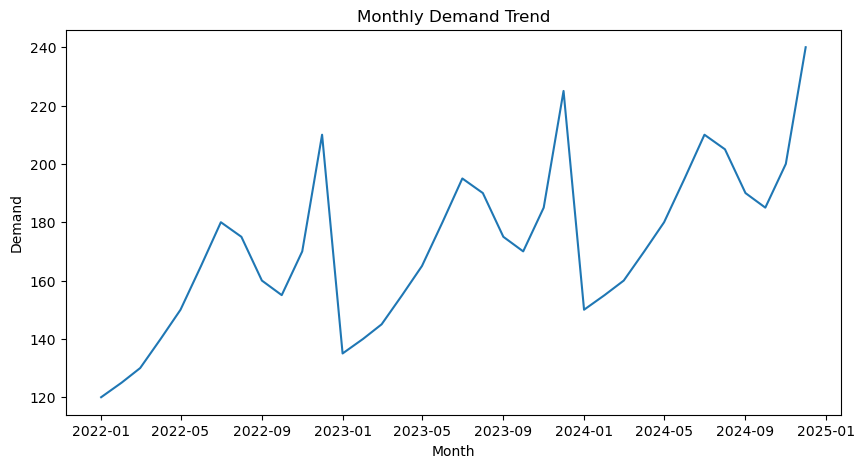

In [5]:
plt.figure(figsize=(10,5))
plt.plot(df['Month'], df['Demand'])
plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Demand")
plt.show()

In [6]:
df['Lag_1'] = df['Demand'].shift(1)
df['Lag_2'] = df['Demand'].shift(2)
print("\nLag Features:")
print(df[['Demand', 'Lag_1', 'Lag_2']].head())


Lag Features:
   Demand  Lag_1  Lag_2
0     120    NaN    NaN
1     125  120.0    NaN
2     130  125.0  120.0
3     140  130.0  125.0
4     150  140.0  130.0


In [7]:
df['Rolling_Mean_3'] = df['Demand'].rolling(3).mean()
df['Rolling_Std_3'] = df['Demand'].rolling(3).std()
print("\nRolling Features:")
print(df[['Rolling_Mean_3','Rolling_Std_3']].head())


Rolling Features:
   Rolling_Mean_3  Rolling_Std_3
0             NaN            NaN
1             NaN            NaN
2      125.000000       5.000000
3      131.666667       7.637626
4      140.000000      10.000000


In [8]:
df = df.dropna()
print("\nShape After Removing Missing Values:")
print(df.shape)
print(df.head())


Shape After Removing Missing Values:
(34, 6)
       Month  Demand  Lag_1  Lag_2  Rolling_Mean_3  Rolling_Std_3
2 2022-03-01     130  125.0  120.0      125.000000       5.000000
3 2022-04-01     140  130.0  125.0      131.666667       7.637626
4 2022-05-01     150  140.0  130.0      140.000000      10.000000
5 2022-06-01     165  150.0  140.0      151.666667      12.583057
6 2022-07-01     180  165.0  150.0      165.000000      15.000000


In [9]:
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]
print("\nTrain Shape:", train.shape)
print("Test Shape :", test.shape)


Train Shape: (27, 6)
Test Shape : (7, 6)


In [10]:
test['Baseline_Pred'] = test['Lag_1']

baseline_mae = mean_absolute_error(test['Demand'],test['Baseline_Pred'])
print("\nBaseline MAE:", baseline_mae)


Baseline MAE: 15.714285714285714


C:\Users\admin\AppData\Local\Temp\ipykernel_17720\1617357286.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Baseline_Pred'] = test['Lag_1']


In [11]:
test['MA_Pred'] = test['Rolling_Mean_3']
ma_mae = mean_absolute_error(test['Demand'],test['MA_Pred'])

print("Moving Average MAE:", ma_mae)

Moving Average MAE: 12.857142857142858


C:\Users\admin\AppData\Local\Temp\ipykernel_17720\1691098512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['MA_Pred'] = test['Rolling_Mean_3']


In [12]:
features = ['Lag_1','Lag_2','Rolling_Mean_3','Rolling_Std_3']

X_train = train[features]
y_train = train['Demand']

X_test = test[features]
y_test = test['Demand']

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)


X_train Shape: (27, 4)
X_test Shape : (7, 4)
y_train Shape: (27,)
y_test Shape : (7,)


In [13]:
model = RandomForestRegressor(n_estimators=100,random_state=42)
model.fit(X_train, y_train)

print("\nModel Training Completed")


Model Training Completed


In [14]:
predictions = model.predict(X_test)

print("\nFirst 5 Predictions:")
print(predictions[:5])


First 5 Predictions:
[183.4  196.45 188.45 187.8  191.35]


In [15]:
mae = mean_absolute_error(y_test,predictions)

rmse = np.sqrt(mean_squared_error(y_test,predictions))

print("\nRandom Forest MAE :", mae)
print("Random Forest RMSE:", rmse)


Random Forest MAE : 13.985714285714286
Random Forest RMSE: 17.897326216904183


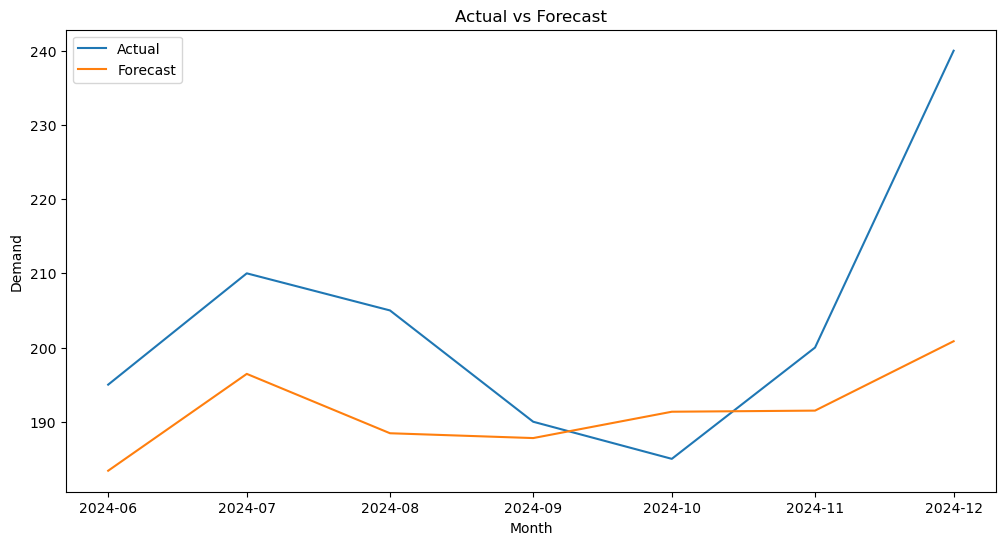

In [16]:
plt.figure(figsize=(12,6))

plt.plot(test['Month'],y_test,label='Actual')

plt.plot(test['Month'],predictions,label='Forecast')

plt.title("Actual vs Forecast")
plt.xlabel("Month")
plt.ylabel("Demand")

plt.legend()

plt.show()